# 21-liver-repertoire-similarity

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import re
import warnings
warnings.filterwarnings('ignore')

DATA = Path("data")

/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
Matplotlib is building the font cache; this may take a moment.
/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
def read_vdj(path: Path):
  adata = ir.io.read_10x_vdj(path)
  ir.pp.index_chains(adata)
  ir.tl.chain_qc(adata)
  return adata

def read_sample(path: Path) -> tuple[ad.AnnData, ad.AnnData, ad.AnnData]:
  mtx = next(path.glob("*_GEX_matrix.mtx.gz"))
  prefix = mtx.name[: -len("matrix.mtx.gz")]

  adata_gex = sc.read_10x_mtx(path, var_names="gene_symbols", prefix=prefix)
  adata_gex.var_names_make_unique()
  sc.pp.filter_cells(adata_gex, min_genes=200)
  sc.pp.filter_genes(adata_gex, min_cells=3)
  adata_gex.var["mt"] = adata_gex.var_names.str.startswith("MT-")
  sc.pp.calculate_qc_metrics(adata_gex, qc_vars=["mt"], inplace=True, log1p=True)
  mu.pp.filter_obs(adata_gex, 'pct_counts_mt', lambda x: x < 10)

  adata_tcr = read_vdj(next(path.glob("*_TCR_filtered_contig_annotations.csv.gz")))
  mu.pp.filter_obs(adata_tcr, "receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
  mu.pp.filter_obs(adata_tcr, "chain_pairing", lambda x: x == "single pair")

  adata_bcr = read_vdj(next(path.glob("*_BCR_filtered_contig_annotations.csv.gz")))
  mu.pp.filter_obs(adata_bcr, "receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
  mu.pp.filter_obs(adata_bcr, "chain_pairing", lambda x: x == "single pair")

  return adata_gex, adata_tcr, adata_bcr


In [3]:
SAMPLE_RE = re.compile(r"Patient(\d+)-(.+)")

adatas_gex = {}
adatas_tcr = {}
adatas_bcr = {}

for sample_dir in sorted(DATA.glob("*/*")):
  if not sample_dir.is_dir():
    continue

  match = SAMPLE_RE.fullmatch(sample_dir.name)
  if not match:
    continue

  sample = sample_dir.name
  patient, condition = match.group(1), match.group(2)
  status = sample_dir.parent.name

  gex, tcr, bcr = read_sample(sample_dir)

  for adata in (gex, tcr, bcr):
    adata.obs["sample"] = sample
    adata.obs["patient"] = patient
    adata.obs["condition"] = condition
    adata.obs["status"] = status
    adata.obs["pre_transplant"] = status == "Pre-TXP"

  adatas_gex[sample] = gex
  adatas_tcr[sample] = tcr
  adatas_bcr[sample] = bcr

adata_gex = ad.concat(adatas_gex, index_unique="_")
adata_tcr = ad.concat(adatas_tcr, index_unique="_")
adata_bcr = ad.concat(adatas_bcr, index_unique="_")

mdata = mu.MuData({
  "gex": adata_gex,
  "tcr": adata_tcr,
  "bcr": adata_bcr,
})

mdata


MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      layers:	None
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

In [4]:
ir.pp.ir_dist(mdata, airr_mod="tcr")
ir.tl.define_clonotypes(mdata, airr_mod="tcr", receptor_arms="all", dual_ir="primary_only")
mdata

MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      layers:	None
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'clone_id', 'clone_id_size'
      uns:	'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

In [5]:
df, dst, lk = ir.tl.repertoire_overlap(mdata, "gex:sample", airr_mod="tcr", inplace=False)
df.head()

clone_id,0,10,1000,1001,1003,1004,1005,1006,1007,1008,...,990,991,992,993,994,995,996,997,998,999
gex:sample,,,,,,,,,,,,,,,,,,,,,
Patient1-Pre-TXP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Patient10-BX1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Patient11-BX1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Patient11-BX2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Patient11-BX3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


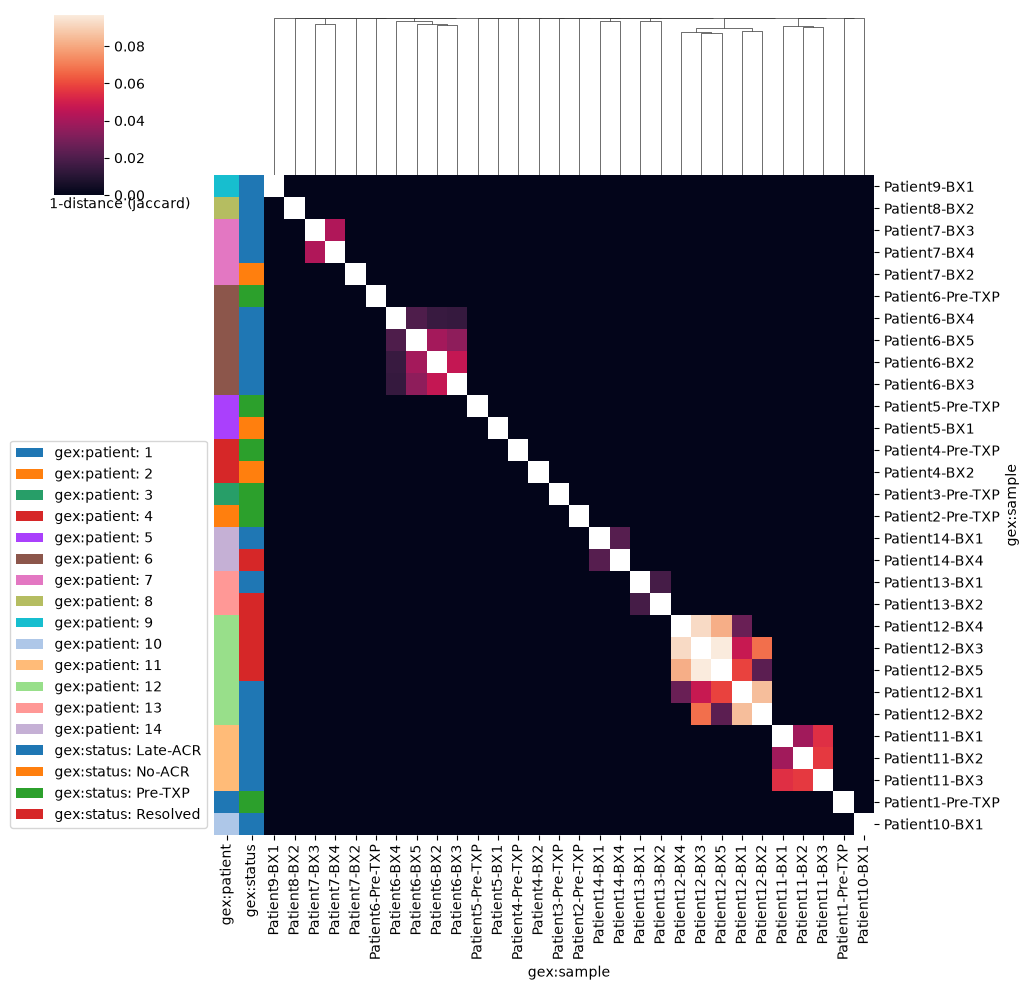

In [6]:
_ = ir.pl.repertoire_overlap(
    mdata,
    "gex:sample",
    airr_mod="tcr",
    heatmap_cats=["gex:patient", "gex:status"],
    yticklabels=True,
    xticklabels=True,
)

<Axes: title={'center': 'Repertoire overlap between Patient12-BX4 and Patient12-BX5'}, xlabel='Clonotype size in Patient12-BX4', ylabel='Clonotype size in Patient12-BX5'>

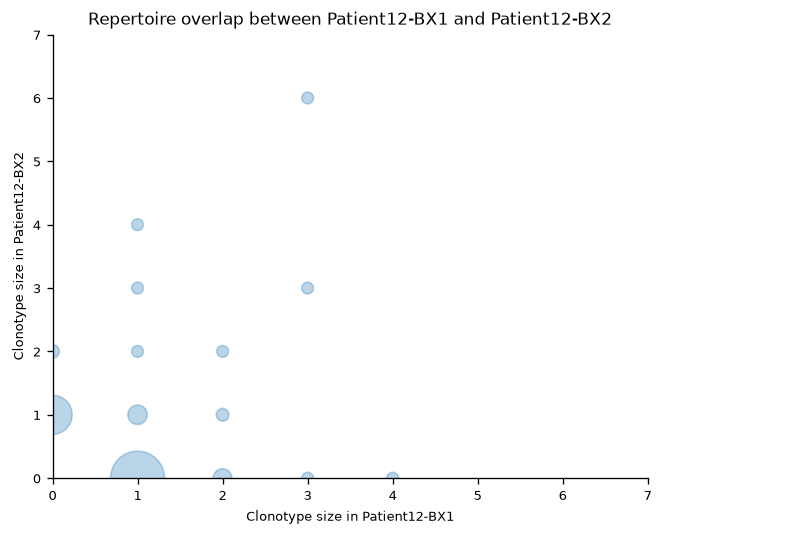

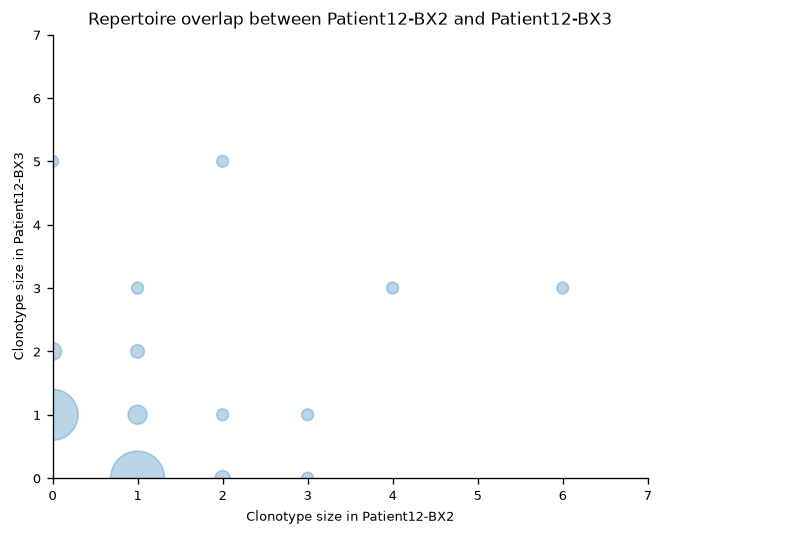

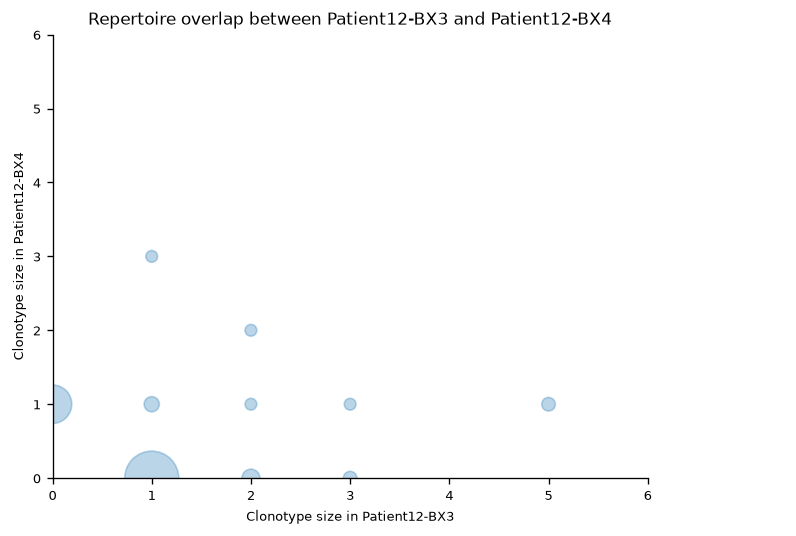

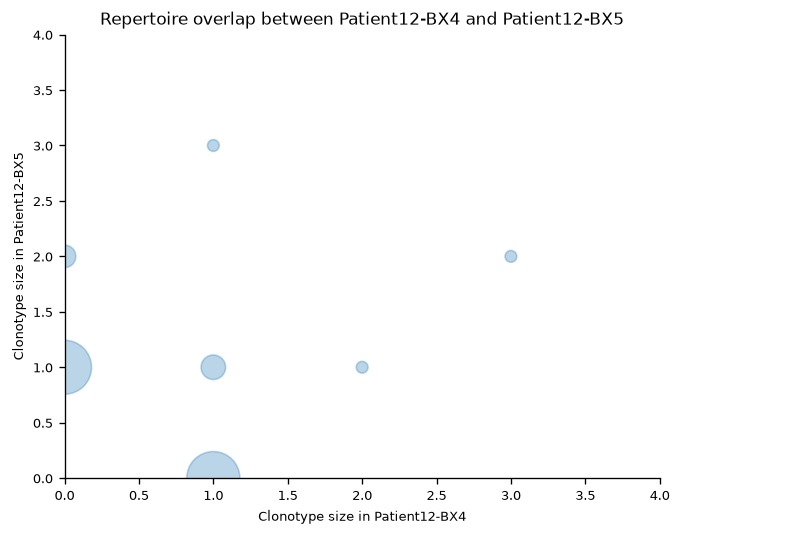

In [10]:
ir.pl.repertoire_overlap(mdata, "tcr:sample", airr_mod="tcr", pair_to_plot=["Patient12-BX1", "Patient12-BX2"], fig_kws={"dpi": 120})

ir.pl.repertoire_overlap(mdata, "tcr:sample", airr_mod="tcr", pair_to_plot=["Patient12-BX2", "Patient12-BX3"], fig_kws={"dpi": 120})

ir.pl.repertoire_overlap(mdata, "tcr:sample", airr_mod="tcr", pair_to_plot=["Patient12-BX3", "Patient12-BX4"], fig_kws={"dpi": 120})

ir.pl.repertoire_overlap(mdata, "tcr:sample", airr_mod="tcr", pair_to_plot=["Patient12-BX4", "Patient12-BX5"], fig_kws={"dpi": 120})

In [8]:
mdata_12 = mdata.copy()
mu.pp.filter_obs(mdata_12, 'tcr:patient', lambda x: x == '12')
mdata_12

MuData object with n_obs × n_vars = 463 × 4829
  3 modalities
    gex:	269 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      layers:	None
    tcr:	463 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'clone_id', 'clone_id_size'
      uns:	'ir_dist_nt_identity', 'clone_id', 'repertoire_overlap'
      obsm:	'airr', 'chain_indices'
    bcr:	0 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

In [9]:
df, _, _ = ir.tl.repertoire_overlap(mdata_12, "tcr:condition", airr_mod="tcr", inplace=False)

corr = df.T.corr(method="pearson")
corr


tcr:condition,BX5,BX2,BX4,BX1,BX3
tcr:condition,,,,,
BX5,1.000000,0.040777,0.191563,0.009273,0.191258
BX2,0.040777,1.000000,0.027165,0.018052,0.204450
BX4,0.191563,0.027165,1.000000,-0.029593,0.154653
BX1,0.009273,0.018052,-0.029593,1.000000,-0.000315
BX3,0.191258,0.204450,0.154653,-0.000315,1.000000
